In [ ]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import os


In [10]:
# this pattern finds all CSVs in current folder
files = glob("*.csv")  # or "data/*.csv" if inside data folder
print("Found files:", files)

all_data = []

for f in files:
    # read each CSV
    df = pd.read_csv(f)
    
    # extract month name from filename (before .csv)
    month_name = os.path.splitext(os.path.basename(f))[0]  # e.g. "Jan_2019"
    
    # add Month column
    df["Month"] = month_name
    all_data.append(df)

# combine all into one DataFrame
combined = pd.concat(all_data, ignore_index=True)

print("Combined shape:", combined.shape)
print(combined.head())


Found files: ['Sales_August_2019.csv', 'Sales_February_2019.csv', 'Sales_January_2019.csv', 'Sales_September_2019.csv']
Combined shape: (45456, 7)
  Order ID                     Product Quantity Ordered Price Each  \
0   236670            Wired Headphones                2      11.99   
1   236671  Bose SoundSport Headphones                1      99.99   
2   236672                      iPhone                1      700.0   
3   236673       AA Batteries (4-pack)                2       3.84   
4   236674       AA Batteries (4-pack)                2       3.84   

       Order Date                      Purchase Address              Month  
0  08/31/19 22:21      359 Spruce St, Seattle, WA 98101  Sales_August_2019  
1  08/15/19 15:11        492 Ridge St, Dallas, TX 75001  Sales_August_2019  
2  08/06/19 14:40        149 7th St, Portland, OR 97035  Sales_August_2019  
3  08/29/19 20:59     631 2nd St, Los Angeles, CA 90001  Sales_August_2019  
4  08/15/19 19:53  736 14th St, New York City, 

C:\Users\Innovative\AppData\Local\Temp\ipykernel_2228\4134318582.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Name', as_index=False)['Sales'].sum()


   Month_Name       Sales
0     January  1815335.12
1    February  2203481.24
2       March        0.00
3       April        0.00
4         May        0.00
5        June        0.00
6        July        0.00
7      August  2244412.31
8   September  2098816.70
9     October        0.00
10   November        0.00
11   December        0.00


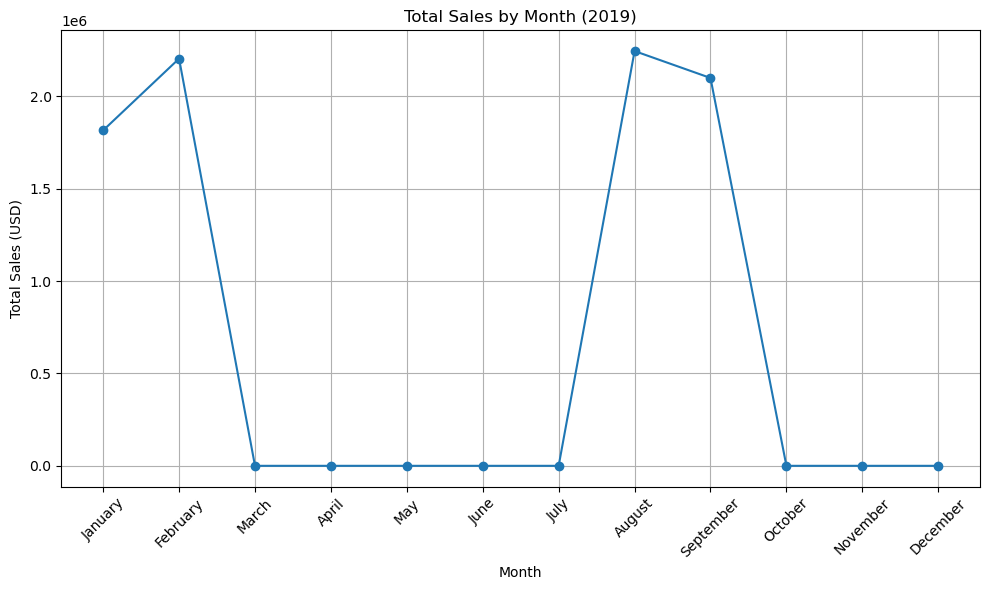

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your combined DataFrame is named `combined`
df = combined.copy()

# 1. Clean Quantity and Price to numeric
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')

# Drop rows with NaNs after conversion
df = df.dropna(subset=['Quantity Ordered', 'Price Each'])

# 2. Compute Sales
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

# 3. Extract Month name from the 'Month' column text
# e.g. 'Sales_August_2019' → 'August'
df['Month_Name'] = df['Month'].str.extract(r'Sales_(\w+)_2019')

# Make a month order mapping
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

# 4. Group by Month and sum Sales
monthly_sales = df.groupby('Month_Name', as_index=False)['Sales'].sum()

print(monthly_sales)

# 5. Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_sales['Month_Name'], monthly_sales['Sales'], marker='o')
plt.title('Total Sales by Month (2019)')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
monthly_sales = df.groupby('Month_Name', as_index=False, observed=False)['Sales'].sum()


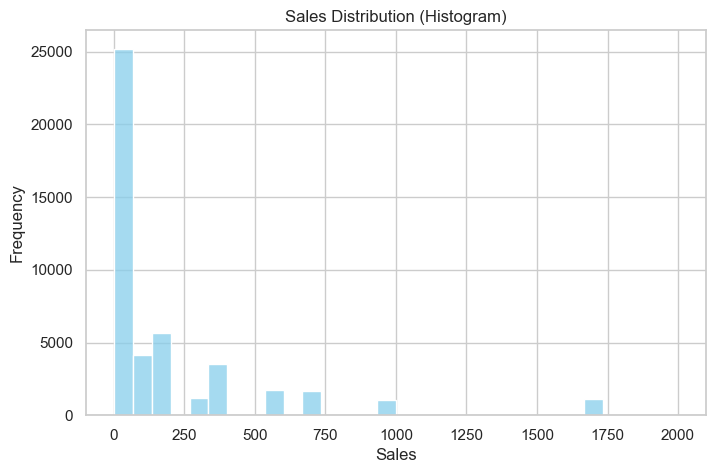

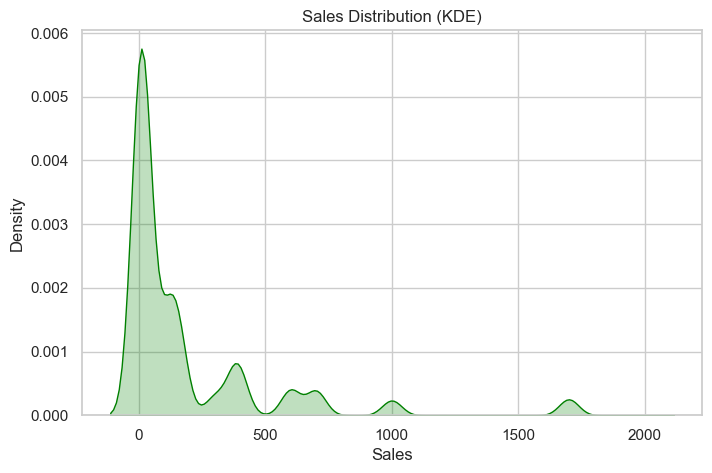

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Sales
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=False, color='skyblue')
plt.title('Sales Distribution (Histogram)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# KDE plot of Sales
plt.figure(figsize=(8,5))
sns.kdeplot(df['Sales'], fill=True, color='green')  # changed shade→fill
plt.title('Sales Distribution (KDE)')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.show()


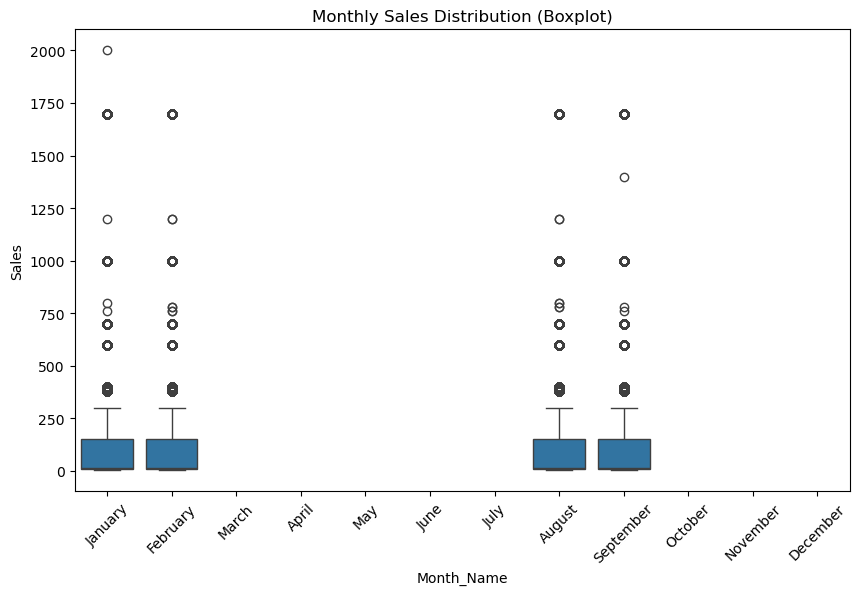

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Month_Name', y='Sales', data=df)
plt.title('Monthly Sales Distribution (Boxplot)')
plt.xticks(rotation=45)
plt.show()


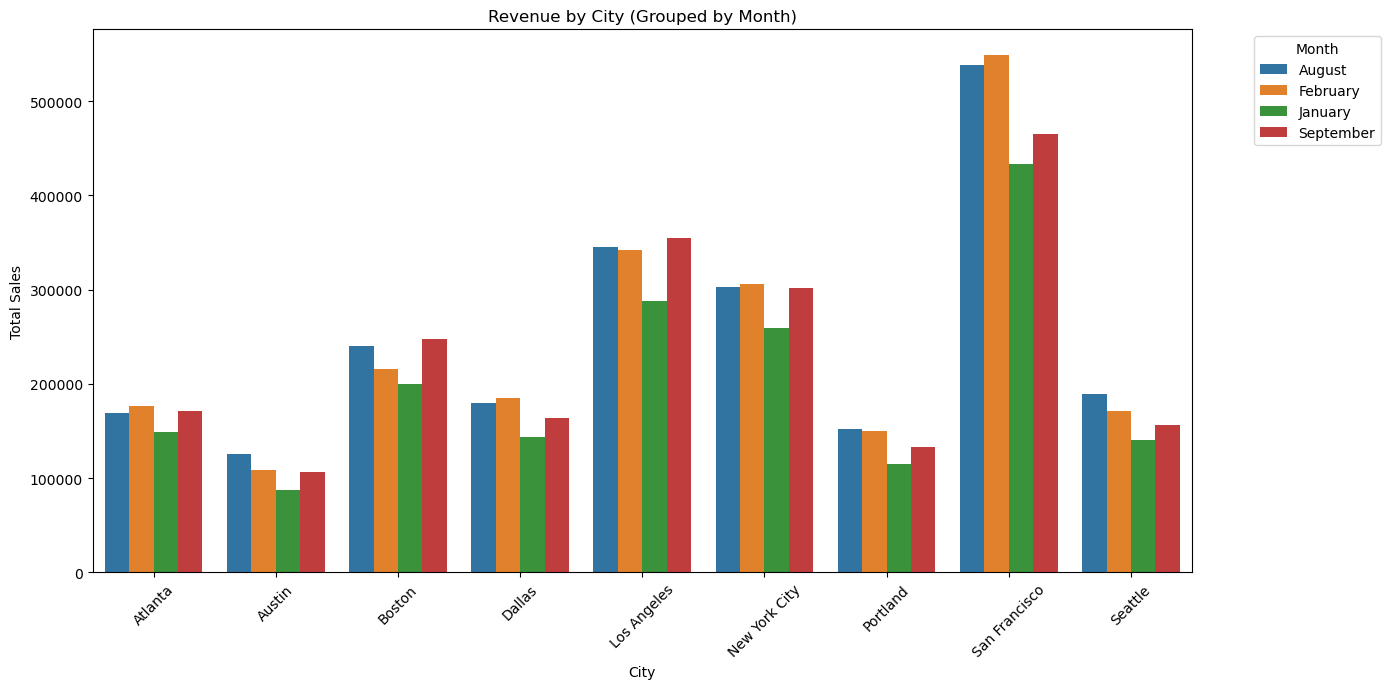

In [24]:
# If Month column is like 'Sales_August_2019', extract the month name:
df['Month_Name'] = df['Month'].str.split('_').str[1]   # 'August'

# Extract Region (or City/State) from Purchase Address:
# e.g. "359 Spruce St, Seattle, WA 98101" → 'Seattle'
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())

# Now you can group:
region_month_sales = df.groupby(['City','Month_Name'], as_index=False)['Sales'].sum()

plt.figure(figsize=(14,7))
sns.barplot(x='City', y='Sales', hue='Month_Name', data=region_month_sales)
plt.title('Revenue by City (Grouped by Month)')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Month', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


In [48]:
print(df.columns.tolist())
print(df[['Month']].head())
print(df.head())


['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'Month_Name', 'City', 'Region']
   Month
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
  Order ID                     Product  Quantity Ordered  Price Each  \
0   236670            Wired Headphones               2.0       11.99   
1   236671  Bose SoundSport Headphones               1.0       99.99   
2   236672                      iPhone               1.0      700.00   
3   236673       AA Batteries (4-pack)               2.0        3.84   
4   236674       AA Batteries (4-pack)               2.0        3.84   

       Order Date                      Purchase Address  Month   Sales  \
0  08/31/19 22:21      359 Spruce St, Seattle, WA 98101    NaN   23.98   
1  08/15/19 15:11        492 Ridge St, Dallas, TX 75001    NaN   99.99   
2  08/06/19 14:40        149 7th St, Portland, OR 97035    NaN  700.00   
3  08/29/19 20:59     631 2nd St, Los Angeles, CA 90001    NaN    7.68   
4

In [55]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%m/%d/%y %H:%M',
    errors='coerce'
)


In [59]:
import calendar
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_name[int(x)] if pd.notnull(x) else None)


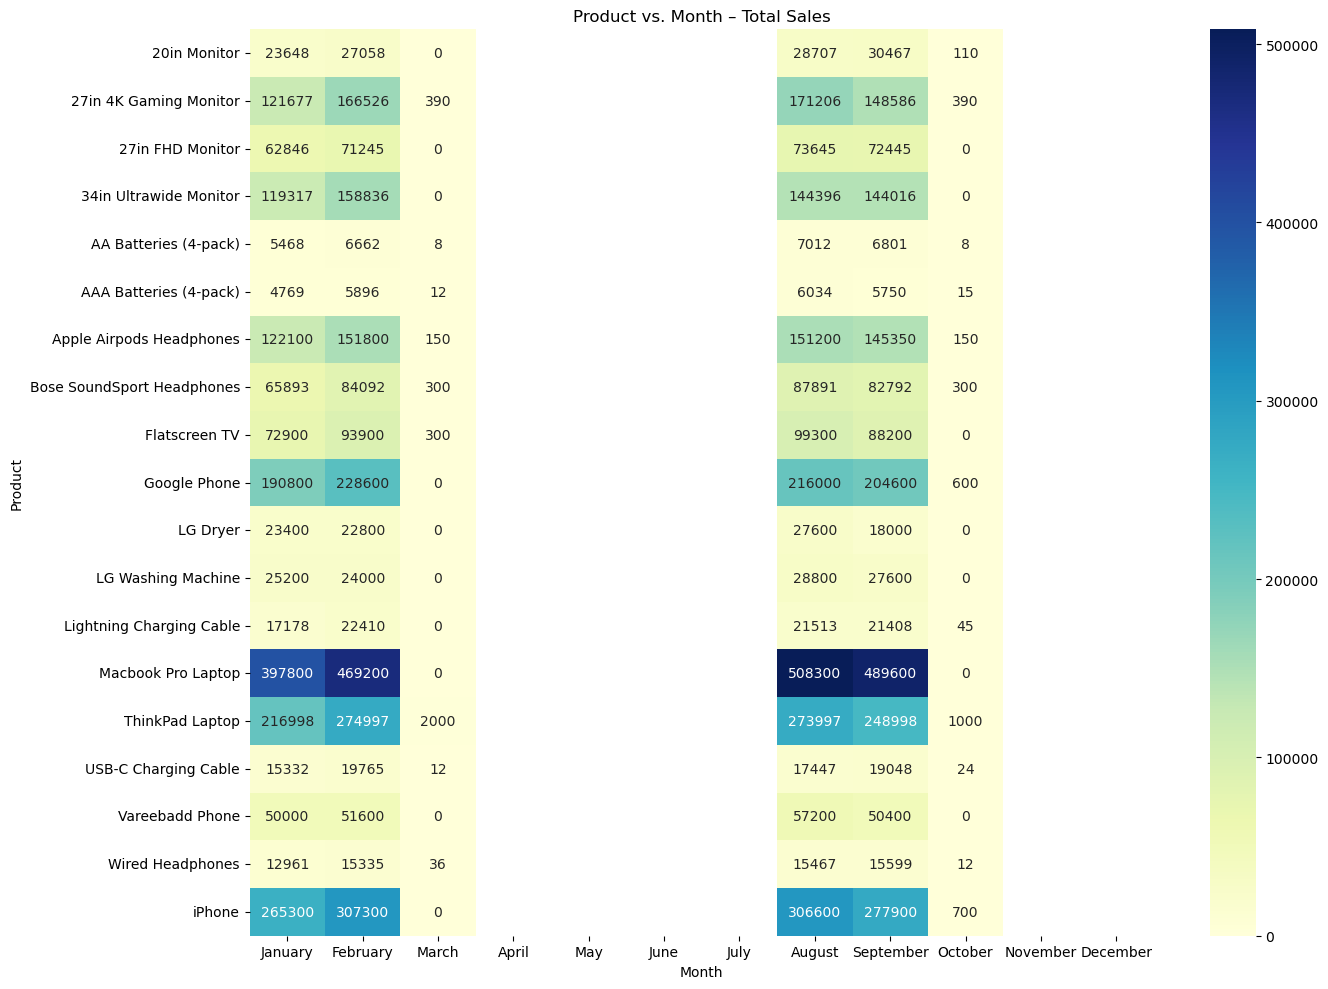

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# --- 1. Parse Order Date correctly ---
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M', errors='coerce')

# --- 2. Extract month number and name ---
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_name[int(x)] if pd.notnull(x) else None)

# --- 3. Group sales by Product and Month ---
grouped = df.groupby(['Product','Month_Name'], as_index=False)['Sales'].sum()

# --- 4. Pivot to get matrix of Product vs Month ---
product_month_pivot = grouped.pivot(index='Product', columns='Month_Name', values='Sales').fillna(0)

# Optional: reorder months Jan–Dec instead of alphabetical
month_order = [calendar.month_name[i] for i in range(1,13)]
product_month_pivot = product_month_pivot.reindex(columns=month_order)

# --- 5. Plot heatmap ---
plt.figure(figsize=(14,10))
sns.heatmap(product_month_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Product vs. Month – Total Sales')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


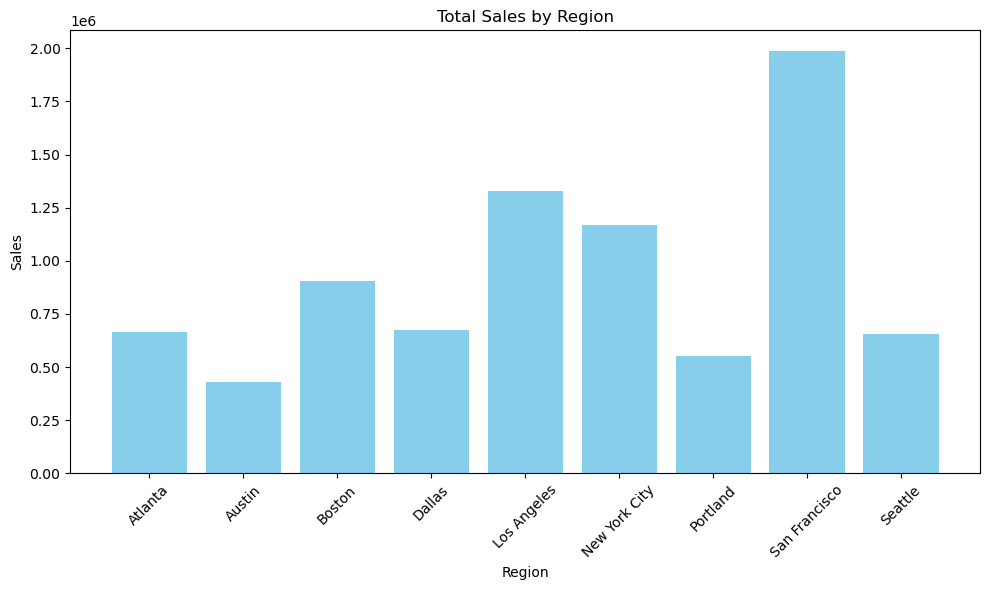

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# group sales by region
region_sales = df.groupby('Region', as_index=False)['Sales'].sum()

# plot
plt.figure(figsize=(10,6))
plt.bar(region_sales['Region'], region_sales['Sales'], color='skyblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


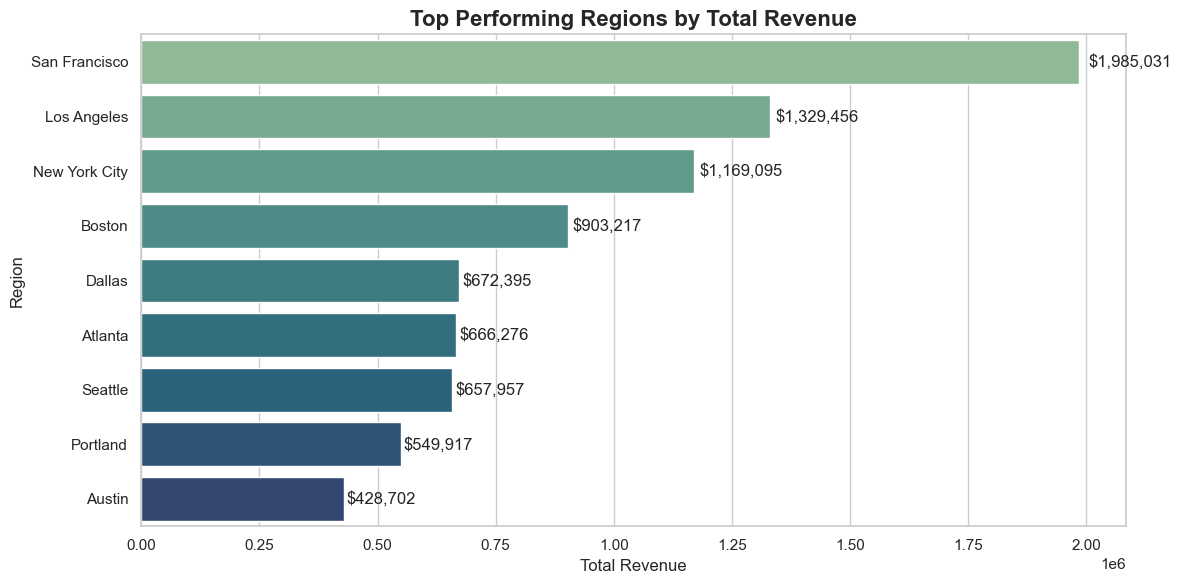

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

# use hue='Region' to satisfy seaborn
ax = sns.barplot(
    data=region_sales,
    y='Region', x='Sales',
    hue='Region', palette='crest', legend=False
)

for i, v in enumerate(region_sales['Sales']):
    ax.text(v + (v*0.01), i, f"${v:,.0f}", va='center')

plt.title('Top Performing Regions by Total Revenue', fontsize=16, weight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


In [71]:
import pandas as pd
import calendar

# Ensure Month column numeric
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')

# Group monthly sales
monthly_sales = df.groupby('Month', as_index=False)['Sales'].sum().sort_values('Month')

# Add month names
monthly_sales['Month_Name'] = monthly_sales['Month'].apply(lambda x: calendar.month_name[int(x)] if pd.notnull(x) else None)

# Calculate MoM growth rate
monthly_sales['MoM_Growth_%'] = monthly_sales['Sales'].pct_change() * 100

print(monthly_sales[['Month_Name', 'Sales', 'MoM_Growth_%']])


  Month_Name       Sales  MoM_Growth_%
0    January  1813586.44           NaN
1   February  2202022.42     21.418112
2      March     3207.50    -99.854338
3     August  2242315.57  69808.513484
4  September  2097560.13     -6.455623
5    October     3353.31    -99.840133


In [74]:
# Extract Year
df['Year'] = pd.to_datetime(df['Order Date'], errors='coerce').dt.year

# Group by Year and Month
year_month_sales = df.groupby(['Year', 'Month'], as_index=False)['Sales'].sum().sort_values(['Month','Year'])

# Compute YoY growth (compare current year to previous year for the same month)
year_month_sales['YoY_Growth_%'] = year_month_sales.groupby('Month')['Sales'].pct_change() * 100

print(year_month_sales)


   Year  Month       Sales  YoY_Growth_%
0  2019      1  1813586.44           NaN
1  2019      2  2202022.42           NaN
2  2019      3     3207.50           NaN
3  2019      8  2242315.57           NaN
4  2019      9  2097560.13           NaN
5  2019     10     3353.31           NaN


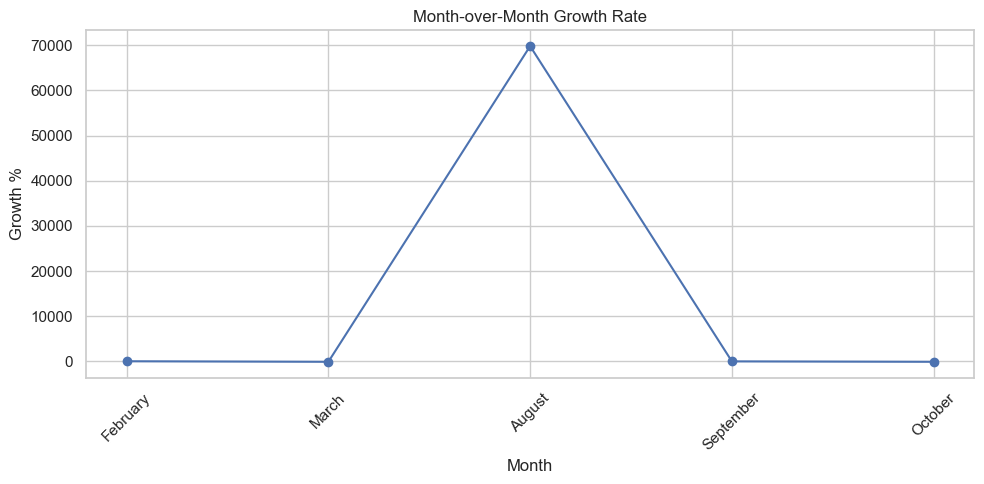

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month_Name'], monthly_sales['MoM_Growth_%'], marker='o')
plt.title('Month-over-Month Growth Rate')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [82]:
# Assume cost = 70% of price
df['Cost'] = df['Price Each'] * 0.7 * df['Quantity Ordered']

# Profit = Sales - Cost
df['Profit'] = df['Sales'] - df['Cost']

# Profit Margin % = Profit / Sales * 100
df['Profit_Margin_%'] = (df['Profit'] / df['Sales']) * 100


<Axes: xlabel='Profit_Margin_%', ylabel='Product'>

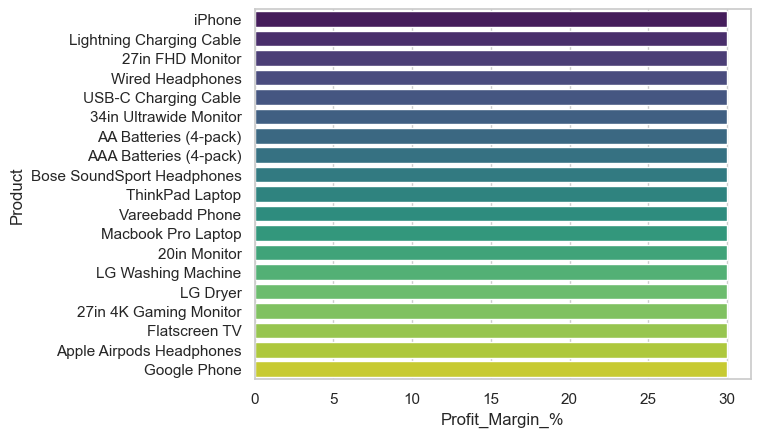

In [90]:
sns.barplot(
    x='Profit_Margin_%', 
    y='Product', 
    hue='Product',             # tell seaborn to color by Product
    data=product_profit.sort_values('Profit_Margin_%', ascending=False),
    palette='viridis',
    legend=False               # no legend clutter
)


In [96]:
import pandas as pd

# 1. Group by Product to get total Sales (Revenue)
product_sales = df.groupby('Product', as_index=False)['Sales'].sum()

# 2. Sort by Sales descending
product_sales = product_sales.sort_values('Sales', ascending=False).reset_index(drop=True)

# 3. Calculate cumulative sales & cumulative % of total
product_sales['Cumulative_Sales'] = product_sales['Sales'].cumsum()
product_sales['Cumulative_%'] = 100 * product_sales['Cumulative_Sales'] / product_sales['Sales'].sum()

# 4. Flag top 20% of products contributing to ~80% of revenue
# (The actual number of products is len(products)*0.2)
num_top_products = int(len(product_sales) * 0.2)
product_sales['Top20%'] = False
product_sales.loc[:num_top_products-1, 'Top20%'] = True

print(product_sales)


                       Product       Sales  Cumulative_Sales  Cumulative_%  \
0           Macbook Pro Laptop  1864900.00        1864900.00     22.301960   
1                       iPhone  1157800.00        3022700.00     36.147855   
2              ThinkPad Laptop  1017989.82        4040689.82     48.321788   
3                 Google Phone   840600.00        4881289.82     58.374352   
4       27in 4K Gaming Monitor   608774.39        5490064.21     65.654561   
5     Apple Airpods Headphones   570750.00        6060814.21     72.480045   
6       34in Ultrawide Monitor   566565.09        6627379.30     79.255481   
7                Flatscreen TV   354600.00        6981979.30     83.496071   
8   Bose SoundSport Headphones   321267.87        7303247.17     87.338048   
9             27in FHD Monitor   280181.32        7583428.49     90.688679   
10             Vareebadd Phone   209200.00        7792628.49     93.190459   
11                20in Monitor   109990.00        7902618.49    

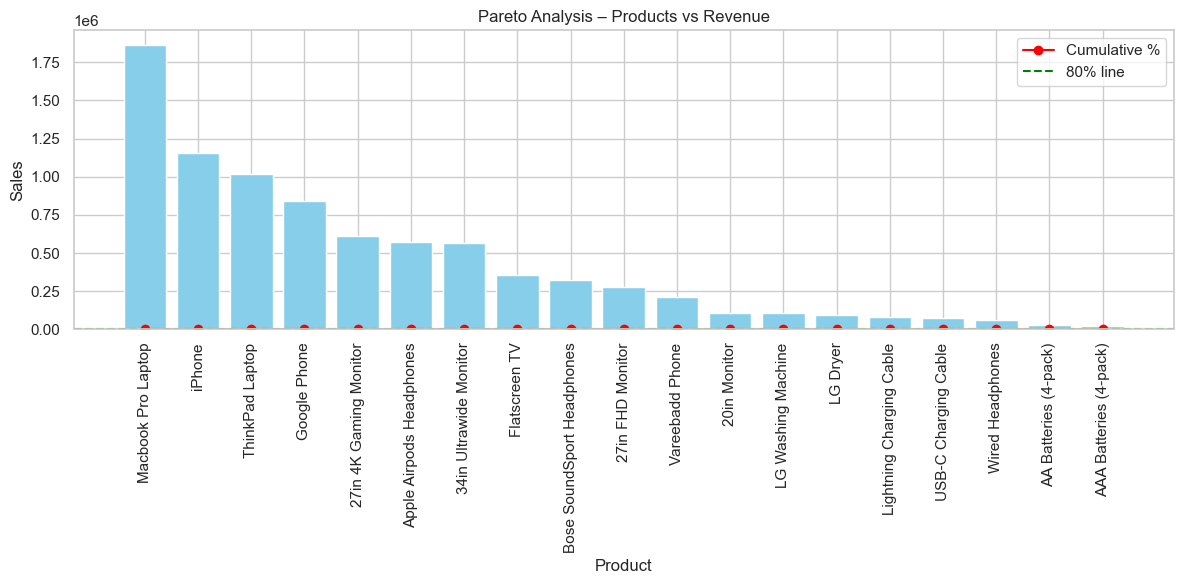

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Bar plot for Sales
plt.bar(product_sales['Product'], product_sales['Sales'], color='skyblue')

# Line plot for cumulative percentage
plt.plot(product_sales['Product'], product_sales['Cumulative_%'], color='red', marker='o', linestyle='-')

# Add 80% line
plt.axhline(80, color='green', linestyle='--', label='80% Revenue')

plt.title('Pareto Analysis – Products vs Revenue')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend(['Cumulative %', '80% line'])
plt.tight_layout()
plt.show()
